<a href="https://colab.research.google.com/github/enriquefroes/futebol-dinheiro-e-desempenho/blob/main/notebooks/01_pontos_por_investimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Pontos por milhão investido em contratações
Quanto rendeu, em pontos, cada milhão gasto em transferências nas duas janelas de 2026.

⚠️ Clubes com `transf_parcial = sim` têm contratações sem valor divulgado: o gasto real é maior e a eficiência real, menor.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_futebol'
except ImportError:
    BASE = './analise_futebol'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (DADOS, GRAF, TAB):
    os.makedirs(p, exist_ok=True)

ARQUIVO = os.path.join(DADOS, 'clubes_2026.csv')
if not os.path.exists(ARQUIVO):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb para criar o CSV no Drive.')
df = pd.read_csv(ARQUIVO)

MESES_DECORRIDOS = 9     # jan a set: usado para comparar custos com os pontos já conquistados
df['pontos_por_jogo'] = df['pontos'] / df['jogos']
df['gasto_transferencias'] = df['gasto_janela1'].fillna(0) + df['gasto_janela2'].fillna(0)
df['folha_anual'] = df['folha_mensal'] * 13
df['folha_ate_agora'] = df['folha_mensal'] * MESES_DECORRIDOS

def rotular(ax, dados, x, y, ajustes=None):
    """Escreve o nome do clube ao lado de cada ponto; 'ajustes' desloca rótulos sobrepostos."""
    ajustes = ajustes or {}
    for _, r in dados.iterrows():
        ax.annotate(r['time'], (r[x], r[y]), xytext=ajustes.get(r['time'], (6, 4)),
                    textcoords='offset points', fontsize=9)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150)
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [ ]:
d = df.copy()
d['pontos_por_milhao'] = d['pontos'] / d['gasto_transferencias']
d['milhoes_por_ponto'] = d['gasto_transferencias'] / d['pontos']

tabela = (d[['time', 'pontos', 'jogos', 'gasto_transferencias', 'pontos_por_milhao', 'milhoes_por_ponto', 'transf_parcial']]
          .sort_values('pontos_por_milhao', ascending=False).round(2))
tabela.to_csv(os.path.join(TAB, '01_pontos_por_milhao_transferencias.csv'), index=False)
print('Correlação gasto x pontos por jogo:', round(d['gasto_transferencias'].corr(d['pontos_por_jogo']), 2))
tabela

Correlação gasto x pontos por jogo: 0.69


,time,pontos,jogos,gasto_transferencias,pontos_por_milhao,milhoes_por_ponto,transf_parcial
13,Corinthians,32,28,4.90,6.53,0.15,nao
19,Chapecoense,18,27,4.20,4.29,0.23,nao
8,Coritiba,38,28,15.00,2.53,0.39,sim
18,Remo,23,28,10.29,2.23,0.45,sim
14,Mirassol,32,28,15.99,2.00,0.50,nao
12,Vitória,33,28,26.23,1.26,0.79,nao
2,Athletico-PR,49,28,59.42,0.82,1.21,nao
10,São Paulo,36,27,47.32,0.76,1.31,nao
17,Internacional,28,28,39.64,0.71,1.42,nao
4,Bahia,46,28,84.64,0.54,1.84,nao


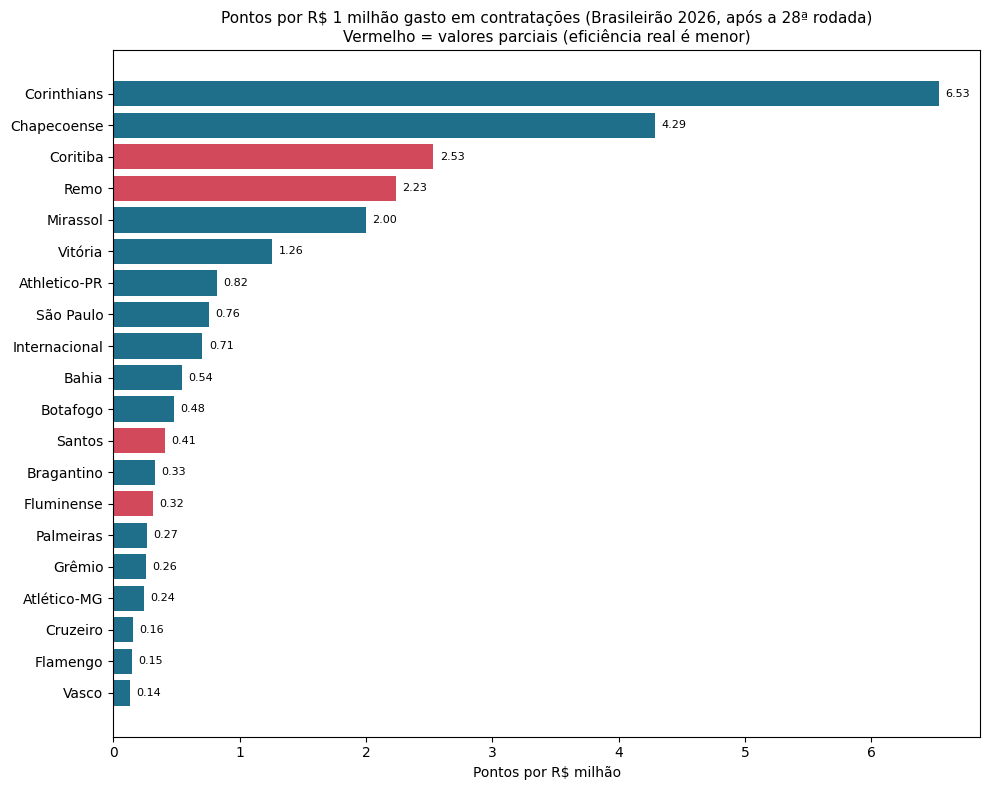

Salvo em /content/drive/MyDrive/analise_futebol/graficos/01a_pontos_por_milhao_transferencias.png


In [ ]:
# Ranking: pontos por R$ 1 milhão investido
t = d.sort_values('pontos_por_milhao')
cores = ['#d1495b' if p == 'sim' else '#1f6f8b' for p in t['transf_parcial']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(t['time'], t['pontos_por_milhao'], color=cores)
for i, v in enumerate(t['pontos_por_milhao']):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=8)
ax.set_title('Pontos por R$ 1 milhão gasto em contratações (Brasileirão 2026, após a 28ª rodada)\n'
             'Vermelho = valores parciais (eficiência real é menor)', fontsize=11)
ax.set_xlabel('Pontos por R$ milhão')
salvar('01a_pontos_por_milhao_transferencias.png')

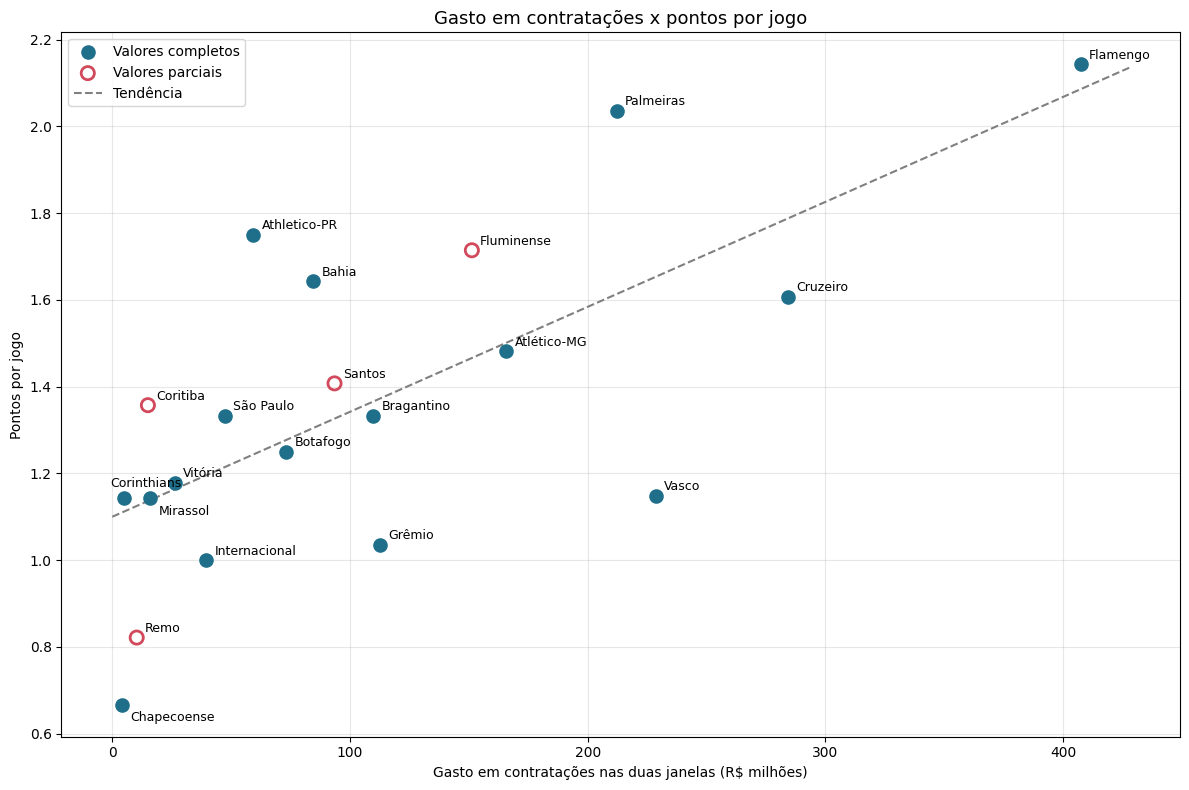

Salvo em /content/drive/MyDrive/analise_futebol/graficos/01b_transferencias_x_pontos.png


In [ ]:
# Dispersão: gasto x pontos por jogo, com linha de tendência
fig, ax = plt.subplots(figsize=(12, 8))
ok, parc = d[d['transf_parcial'] == 'nao'], d[d['transf_parcial'] == 'sim']
ax.scatter(ok['gasto_transferencias'], ok['pontos_por_jogo'], s=90, color='#1f6f8b', label='Valores completos', zorder=3)
ax.scatter(parc['gasto_transferencias'], parc['pontos_por_jogo'], s=90, facecolors='none', edgecolors='#d1495b',
           linewidths=2, label='Valores parciais', zorder=3)
coef = np.polyfit(d['gasto_transferencias'], d['pontos_por_jogo'], 1)
xs = np.linspace(0, d['gasto_transferencias'].max() * 1.05, 100)
ax.plot(xs, np.polyval(coef, xs), '--', color='gray', label='Tendência')
rotular(ax, d, 'gasto_transferencias', 'pontos_por_jogo',
        {'Mirassol': (6, -12), 'Corinthians': (-10, 8), 'Chapecoense': (6, -12)})
ax.set_title('Gasto em contratações x pontos por jogo', fontsize=13)
ax.set_xlabel('Gasto em contratações nas duas janelas (R$ milhões)')
ax.set_ylabel('Pontos por jogo')
ax.grid(alpha=0.3); ax.legend(loc='upper left')
salvar('01b_transferencias_x_pontos.png')